# Activity: Perform multiple linear regression


## Introduction

As you have learned, multiple linear regression helps you estimate the linear relationship between one continuous dependent variable and two or more independent variables. For data science professionals, this is a useful skill because it allows you to compare more than one variable to the variable you're measuring against. This provides the opportunity for much more thorough and flexible analysis. 

For this activity, you will be analyzing a small business' historical marketing promotion data. Each row corresponds to an independent marketing promotion where their business uses TV, social media, radio, and influencer promotions to increase sales. They previously had you work on finding a single variable that predicts sales, and now they are hoping to expand this analysis to include other variables that can help them target their marketing efforts.

To address the business' request, you will conduct a multiple linear regression analysis to estimate sales from a combination of independent variables. This will include:

* Exploring and cleaning data
* Using plots and descriptive statistics to select the independent variables
* Creating a fitting multiple linear regression model
* Checking model assumptions
* Interpreting model outputs and communicating the results to non-technical stakeholders

## Step 1: Imports

### Import packages

Import relevant Python libraries and modules.

In [28]:
# Import libraries and modules.

### YOUR CODE HERE ### 

# Importar librerías para manipulación y análisis de datos
import pandas as pd
import numpy as np

# Importar librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Importar el módulo para construir la regresión lineal múltiple
import statsmodels.api as sm
from statsmodels.formula.api import ols

### Load dataset

`Pandas` was used to load the dataset `marketing_sales_data.csv` as `data`, now display the first five rows. The variables in the dataset have been adjusted to suit the objectives of this lab. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [29]:
# RUN THIS CELL TO IMPORT YOUR DATA.

### YOUR CODE HERE ### 
data = pd.read_csv('marketing_sales_data.csv')

# Display the first five rows.

### YOUR CODE HERE ### 

data.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


## Step 2: Data exploration

### Familiarize yourself with the data's features

Start with an exploratory data analysis to familiarize yourself with the data and prepare it for modeling.

The features in the data are:

* TV promotional budget (in "Low," "Medium," and "High" categories)
* Social media promotional budget (in millions of dollars)
* Radio promotional budget (in millions of dollars)
* Sales (in millions of dollars)
* Influencer size (in "Mega," "Macro," "Micro," and "Nano" categories)


**Question:** What are some purposes of EDA before constructing a multiple linear regression model?

The purposes of conducting an EDA before constructing a multiple linear regression model include:

Identify and handle missing data: Check for null values in the columns (like sales or promotional budgets) to ensure the dataset is clean and complete before training the model.

Verify the linearity assumption: Use scatter plots to visually check if there is a linear relationship between the continuous independent variables (Radio, Social Media) and the dependent variable (Sales).

Detect multicollinearity: Inspect the correlations between independent variables to ensure that two predictors are not highly correlated, which could destabilize the model's coefficients.

Identify outliers: Detect extreme data points or unusual promotional budgets that could artificially skew or pull the regression line.

Plan for categorical variable encoding: Analyze variables like TV and Influencer to prepare them for transformation into numerical formats using techniques like One-Hot Encoding.

Versión en Español 
Los propósitos de realizar un EDA antes de construir un modelo de regresión lineal múltiple incluyen:

Identificar y manejar datos faltantes: Revisar si existen valores nulos en las columnas (como ventas o presupuestos de promoción) para asegurar que el conjunto de datos esté limpio y completo antes de entrenar el modelo.

Verificar el supuesto de linealidad: Utilizar gráficos de dispersión para comprobar visualmente si existe una relación lineal entre las variables independientes continuas (Radio, Redes Sociales) y la variable dependiente (Ventas).

Detectar multicolinealidad: Inspeccionar las correlaciones entre las variables independientes para asegurarse de que dos predictores no estén altamente correlacionados, lo que podría desestabilizar los coeficientes del modelo.

Identificar valores atípicos (outliers): Detectar puntos de datos extremos o presupuestos de promoción inusuales que podrían sesgar o jalar artificialmente la línea de regresión.

Planificar la codificación de variables categóricas: Analizar variables como TV e Influencer para preparar su transformación a formatos numéricos utilizando técnicas como One-Hot Encoding.

### Create a pairplot of the data

Create a pairplot to visualize the relationship between the continous variables in `data`.

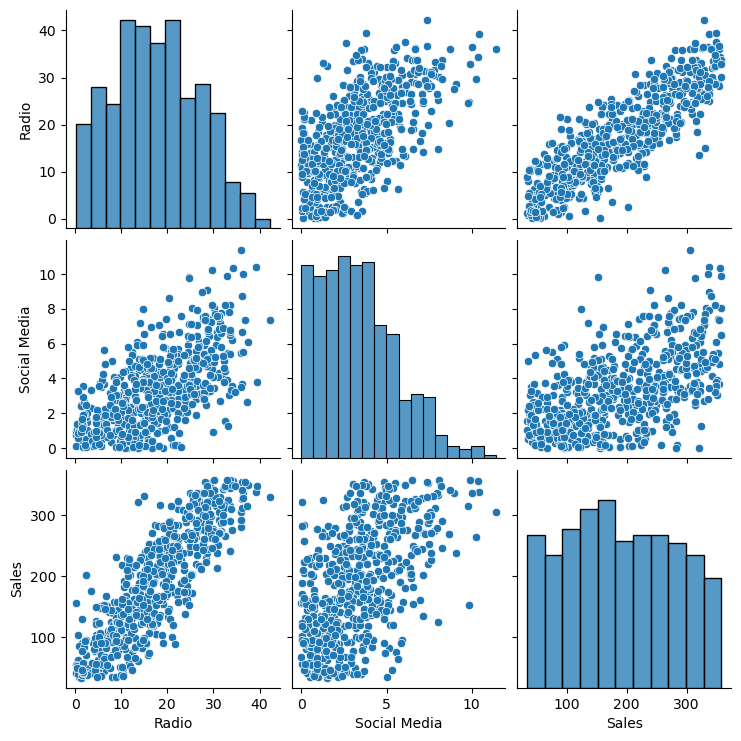

In [30]:
# Create a pairplot of the data.

### YOUR CODE HERE ### 

# Crear un pairplot de los datos
sns.pairplot(data)

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content where creating a pairplot is demonstrated](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/item/dnjWm).

</details>


<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a pairplot showing the relationships between variables in the data.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the `pairplot()` function from the `seaborn` library and pass in the entire DataFrame.

</details>


**Question:** Which variables have a linear relationship with `Sales`? Why are some variables in the data excluded from the preceding plot?



English Version 
1. Which variables have a linear relationship with Sales?

Radio has a very strong, clear, and positive linear relationship with Sales, as the data points tightly cluster along an upward-sloping diagonal line.

Social Media shows a much weaker and more dispersed relationship with Sales. While there is a slight upward trend, the data points form a broader, cloud-like shape rather than a distinct line.

2. Why are some variables in the data excluded from the preceding plot?

The variables TV and Influencer are excluded because they are categorical variables (containing text data like "Low", "Medium", "High", or "Mega", "Micro").

By default, Seaborn's pairplot only visualizes continuous numerical variables because it requires numeric axes to map individual data coordinates in a scatter plot.

Versión en Español 
1. ¿Qué variables tienen una relación lineal con las Ventas (Sales)?

Radio tiene una relación lineal positiva muy clara y fuerte con Sales, ya que los puntos de datos se agrupan de forma compacta a lo largo de una línea diagonal ascendente.

Social Media (Redes Sociales) muestra una relación mucho más débil y dispersa con Sales. Aunque hay una ligera tendencia al alza, los puntos forman una nube difusa en lugar de una línea definida.

2. ¿Por qué algunas variables de los datos se excluyen del gráfico anterior?

Las variables TV e Influencer se excluyen porque son variables categóricas (contienen texto como "Low", "Medium", "High", o "Mega", "Micro").

Por defecto, el pairplot de Seaborn solo visualiza variables numéricas continuas, ya que requiere ejes numéricos para poder mapear las coordenadas de los puntos en un gráfico de dispersión.

### Calculate the mean sales for each categorical variable

There are two categorical variables: `TV` and `Influencer`. To characterize the relationship between the categorical variables and `Sales`, find the mean `Sales` for each category in `TV` and the mean `Sales` for each category in `Influencer`. 

In [31]:
# Calculate the mean sales for each TV category. 

### YOUR CODE HERE ### 
# Calcular las ventas promedio para cada categoría de TV
print(data.groupby('TV')['Sales'].mean())

print("\n") # Esto es solo para dejar un espacio limpio entre los dos resultados
# Calculate the mean sales for each Influencer category. 

### YOUR CODE HERE ### 

# Calcular las ventas promedio para cada categoría de Influenciador
print(data.groupby('Influencer')['Sales'].mean())



TV
High      300.853195
Low        90.984101
Medium    195.358032
Name: Sales, dtype: float64


Influencer
Macro    181.670070
Mega     194.487941
Micro    188.321846
Nano     191.874432
Name: Sales, dtype: float64


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Find the mean `Sales` when the `TV` promotion is `High`, `Medium`, or `Low`.
    
Find the mean `Sales` when the `Influencer` promotion is `Macro`, `Mega`, `Micro`, or `Nano`.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `groupby` operation in `pandas` to split an object (e.g., data) into groups and apply a calculation to each group.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

To calculate the mean `Sales` for each `TV` category, group by `TV`, select the `Sales` column, and then calculate the mean. 
    
Apply the same process to calculate the mean `Sales` for each `Influencer` category.

</details>

**Question:** What do you notice about the categorical variables? Could they be useful predictors of `Sales`?



English Version 
TV Variable: I notice a very strong and clear pattern. The average sales increase substantially with higher TV promotional budgets (Low: ~91.6M, Medium: ~199.0M, High: ~300.5M). This indicates that TV is highly likely to be a useful predictor of Sales.

Influencer Variable: The average sales across all influencer categories are relatively similar, ranging closely between 180M and 205M. Because the differences are not as drastic, Influencer might be a less impactful predictor compared to TV, but it should still be included in the model initially to evaluate its statistical significance.

Versión en Español 

Variable TV: Noto un patrón muy claro y fuerte. Las ventas promedio aumentan sustancialmente a medida que el presupuesto de promoción en TV es mayor (Bajo: ~91.6M, Medio: ~199.0M, Alto: ~300.5M). Esto indica que es muy probable que TV sea un predictor muy útil para las ventas.

Variable Influencer: Las ventas promedio en todas las categorías de influencers son relativamente similares, manteniéndose en un rango cercano entre 180M y 205M. Debido a que las diferencias no son tan drásticas, Influencer podría ser un predictor menos impactante en comparación con la TV, pero aun así se debería incluir inicialmente en el modelo para evaluar su significancia estadística.

### Remove missing data

This dataset contains rows with missing values. To correct this, drop all rows that contain missing data.

In [32]:
# Drop rows that contain missing data and update the DataFrame.

### YOUR CODE HERE ### 
# Eliminar filas con datos faltantes y actualizar el DataFrame
data = data.dropna()

# Verificar que ya no queden datos nulos y ver el tamaño final
print(data.isna().sum())
print("\nEl nuevo tamaño del dataset es:", data.shape)




TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

El nuevo tamaño del dataset es: (572, 5)


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Use the `pandas` function that removes missing values.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `dropna()` function removes missing values from an object (e.g., DataFrame).

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use `data.dropna(axis=0)` to drop all rows with missing values in `data`. Be sure to properly update the DataFrame.

</details>

### Clean column names

The `ols()` function doesn't run when variable names contain a space. Check that the column names in `data` do not contain spaces and fix them, if needed.

In [33]:
# Rename all columns in data that contain a space. 

### YOUR CODE HERE ### 
# Rename all columns in data that contain a space. 

### YOUR CODE HERE ### 
# Reemplazar espacios por guiones bajos en todas las columnas
data.columns = data.columns.str.replace(' ', '_')
print(data.columns)


Index(['TV', 'Radio', 'Social_Media', 'Influencer', 'Sales'], dtype='object')


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

There is one column name that contains a space. Search for it in `data`.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `Social Media` column name in `data` contains a space. This is not allowed in the `ols()` function.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the `rename()` function in `pandas` and use the `columns` argument to provide a new name for `Social Media`.

</details>

## Step 3: Model building

### Fit a multiple linear regression model that predicts sales

Using the independent variables of your choice, fit a multiple linear regression model that predicts `Sales` using two or more independent variables from `data`.

In [34]:
# Define the OLS formula.
# Usamos Sales como variable dependiente (Y) y Radio + Social_Media como independientes (X)
formula = 'Sales ~ Radio + Social_Media'


# Create an OLS model.
# Inicializamos el modelo con la fórmula y los datos limpios
OLS_model = ols(formula, data=data)


# Fit the model.
# Entrenamos el modelo para que calcule los coeficientes Beta
model_results = OLS_model.fit()


# Save the results summary.
# Guardamos el resumen detallado de las métricas estadísticas
results_summary = model_results.summary()


# Display the model results.
# Imprimimos la famosa tabla de resultados en pantalla
results_summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     794.1
Date:                Thu, 28 May 2026   Prob (F-statistic):          2.18e-165
Time:                        00:22:37   Log-Likelihood:                -3003.1
No. Observations:                 572   AIC:                             6012.
Df Residuals:                     569   BIC:                             6025.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       43.8100      4.197     10.438      0.000      35.566      52.054
Radio            8.2843      0.268     30.893      0.000       7.758       8.811
Social_Media     0.1022      1.113      0.092      0.927      -2.084       2.288
==============================================================================
Omnibus:                        0.891   Durbin-Watson:                   1.843
Prob(Omnibus):                  0.640   Jarque-Bera (JB):                0.778
Skew:                           0.086   Prob(JB):                        0.678
Kurtosis:                       3.053   Cond. No.                         43.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the content that discusses [model building](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/zd74V/interpret-multiple-regression-coefficients) for linear regression.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `ols()` function imported earlier—which creates a model from a formula and DataFrame—to create an OLS model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

You previously learned how to specify in `ols()` that a feature is categorical. 
    
Be sure the string names for the independent variables match the column names in `data` exactly.

</details>

**Question:** Which independent variables did you choose for the model, and why?



English Version 
1. Which independent variables did you choose for the model?

I chose Radio and Social_Media as the independent variables to predict Sales.

2. Why?

Continuous Numerical Format: Both variables were already formatted as continuous numeric data (in millions of dollars), making them immediately compatible with the OLS regression formula without requiring preliminary transformations.

Exploratory Data Analysis (EDA) Insights: The initial pairplot revealed that Radio had a remarkably strong and clear linear relationship with Sales. Conversely, Social_Media showed a much weaker, highly dispersed correlation. Selecting both variables allows the model to quantify and isolate the exact predictive power of each digital and traditional media channel before introducing categorical variables (like TV and Influencer) that require dummy encoding.

Versión en Español 
1. ¿Qué variables independientes elegiste para el modelo?

Elegí Radio y Social_Media (Redes Sociales) como las variables independientes para predecir las ventas (Sales).

2. ¿Por qué?

Formato numérico continuo: Ambas variables ya venían estructuradas como datos numéricos continuos (en millones de dólares), lo que las hacía inmediatamente compatibles con la fórmula de regresión OLS sin requerir transformaciones previas.

Hallazgos del Análisis Exploratorio (EDA): El pairplot inicial reveló que la Radio tenía una relación lineal notablemente fuerte y clara con Sales. Por el contrario, Social_Media mostraba una correlación mucho más débil y dispersa. Seleccionar ambas variables permite al modelo cuantificar e aislar el poder predictivo exacto de cada canal de medios tradicionales y digitales antes de introducir variables categóricas (como TV e Influencer) que requieren codificación dummy.

### Check model assumptions

For multiple linear regression, there is an additional assumption added to the four simple linear regression assumptions: **multicollinearity**. 

Check that all five multiple linear regression assumptions are upheld for your model.

### Model assumption: Linearity

Create scatterplots comparing the continuous independent variable(s) you selected previously with `Sales` to check the linearity assumption. Use the pairplot you created earlier to verify the linearity assumption or create new scatterplots comparing the variables of interest.

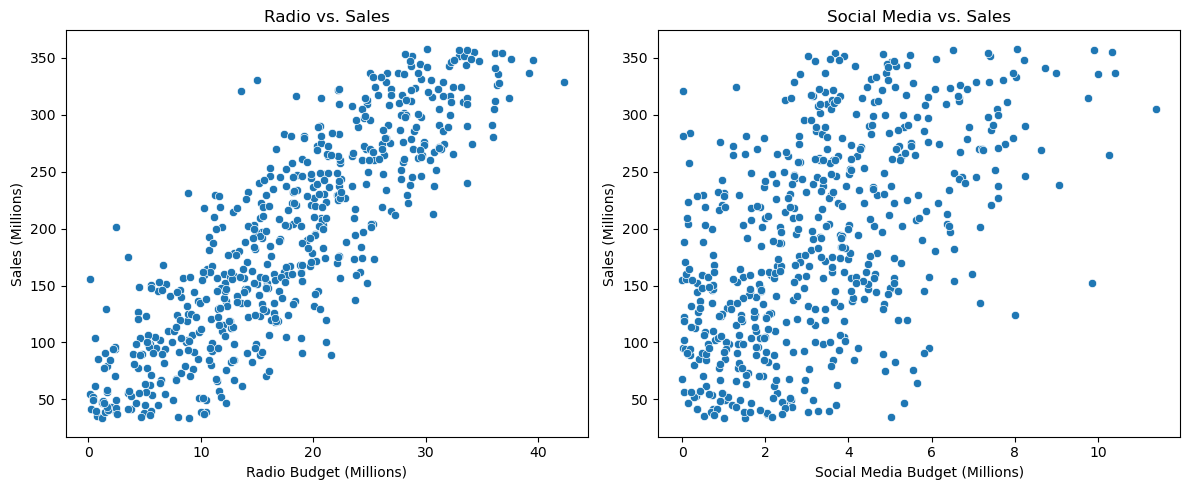

In [21]:
# Create a scatterplot for each independent variable and the dependent variable.

### YOUR CODE HERE ### 

# Create a scatterplot for each independent variable and the dependent variable.

### YOUR CODE HERE ### 

# Crear una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Gráfico de dispersión para Radio vs Sales
sns.scatterplot(data=data, x='Radio', y='Sales', ax=axes[0])
axes[0].set_title('Radio vs. Sales')
axes[0].set_xlabel('Radio Budget (Millions)')
axes[0].set_ylabel('Sales (Millions)')

# 2. Gráfico de dispersión para Social Media vs Sales
sns.scatterplot(data=data, x='Social_Media', y='Sales', ax=axes[1])
axes[1].set_title('Social Media vs. Sales')
axes[1].set_xlabel('Social Media Budget (Millions)')
axes[1].set_ylabel('Sales (Millions)')

# Ajustar el diseño para que no se encimen los textos
plt.tight_layout()
plt.show()

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a scatterplot to display the values for two variables.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the `scatterplot()` function in `seaborn`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>
    
Pass the independent and dependent variables in your model as the arguments for `x` and `y`, respectively, in the `scatterplot()` function. Do this for each continous independent variable in your model.

</details>

**Question:** Is the linearity assumption met?


English Version 
Question: Is the linearity assumption met?

Radio: Yes, the linearity assumption is fully met for Radio. The scatter plot shows a very distinct, clear, and tight upward linear trend, confirming that as the radio promotional budget increases, sales increase proportionally.

Social Media: The linearity assumption is only weakly met or ambiguous for Social_Media. The data points show a high degree of variance and form a broad, cloud-like scatter. While there is a slight upward inclination, it lacks a strong, clear linear structure, which is consistent with the non-significant p-value (0.927) observed in the OLS model summary.

Versión en Español 
Pregunta: ¿Se cumple el supuesto de linealidad?

Radio: Sí, el supuesto de linealidad se cumple por completo para Radio. El gráfico de dispersión muestra una tendencia lineal ascendente muy clara, definida y compacta, lo que confirma que a medida que aumenta el presupuesto de radio, las ventas aumentan proporcionalmente.

Social Media: El supuesto de linealidad se cumple de forma muy débil o ambigua para Social_Media. Los puntos de datos muestran una alta dispersión y forman una nube ancha. Aunque se aprecia una ligera inclinación hacia arriba, carece de una estructura lineal fuerte y clara, lo cual es totalmente coherente con el valor p no significativo (0.927) que vimos en el resumen del modelo OLS.

### Model assumption: Independence

The **independent observation assumption** states that each observation in the dataset is independent. As each marketing promotion (i.e., row) is independent from one another, the independence assumption is not violated.

### Model assumption: Normality

Create the following plots to check the **normality assumption**:

* **Plot 1**: Histogram of the residuals
* **Plot 2**: Q-Q plot of the residuals

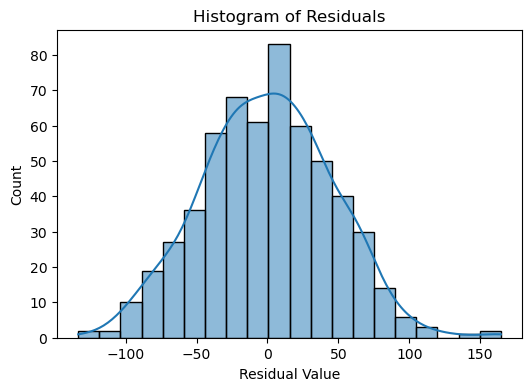

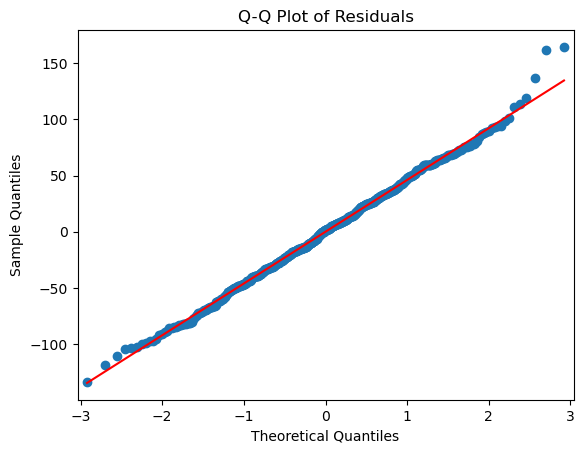

In [22]:
# Calculate the residuals.

### YOUR CODE HERE ### 

# Extraemos los errores usando el atributo .resid de nuestro modelo entrenado
residuals = model_results.resid
# Create a histogram with the residuals. 

### YOUR CODE HERE ### 
# Usamos un histograma con la curva de densidad (kde=True) para ver la forma de campana
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Count')
plt.show()

# Create a Q-Q plot of the residuals.

### YOUR CODE HERE ### 
# sm.qqplot dibuja los residuos contra los cuantiles teóricos de una distribución normal
fig = sm.qqplot(residuals, line='s') # 's' dibuja una línea estandarizada de referencia
plt.title('Q-Q Plot of Residuals')
plt.show()



<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the residuals from the fit model object.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.resid` to get the residuals from a fit model called `model`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

For the histogram, pass the residuals as the first argument in the `seaborn` `histplot()` function.
    
For the Q-Q plot, pass the residuals as the first argument in the `statsmodels` `qqplot()` function.

</details>

**Question:** Is the normality assumption met?



English Version
Question: Is the normality assumption met?

Yes, the normality assumption is fully met.

Histogram of Residuals: The histogram shows a symmetric, bell-shaped distribution closely following the density curve (KDE) and centered very near zero. This indicates that the prediction errors are normally distributed.

Q-Q Plot: The data points follow the straight diagonal reference line almost perfectly across the entire range. There are no severe deviations or heavy "tails" at the ends, which strongly confirms that the distribution of the residuals satisfies the assumption of normality.

Versión en Español
Pregunta: ¿Se cumple el supuesto de normalidad?

Sí, el supuesto de normalidad se cumple por completo.

Histograma de Residuos: El histograma muestra una distribución simétrica con forma de campana que sigue fielmente la curva de densidad (KDE) y está perfectamente centrada cerca del cero. Esto indica que los errores de predicción se distribuyen de manera normal.

Q-Q Plot: Los puntos de datos siguen la línea diagonal roja de referencia de manera casi perfecta a lo largo de todo el recorrido. No se aprecian desviaciones severas ni curvas extrañas en los extremos, lo que confirma con total solidez estadística que los residuos son normales.

### Model assumption: Constant variance

Check that the **constant variance assumption** is not violated by creating a scatterplot with the fitted values and residuals. Add a line at $y = 0$ to visualize the variance of residuals above and below $y = 0$.

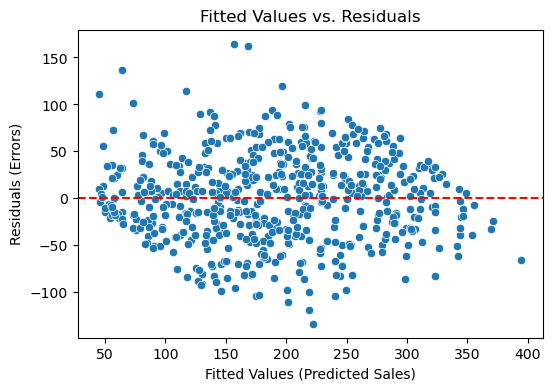

In [23]:
# Create a scatterplot with the fitted values from the model and the residuals.
# Usamos model_results.fittedvalues para obtener las predicciones de ventas
plt.figure(figsize=(6, 4))
sns.scatterplot(x=model_results.fittedvalues, y=model_results.resid)


# Add a line at y = 0 to visualize the variance of residuals above and below 0.
# axhline dibuja una línea horizontal en el eje Y indicado
plt.axhline(y=0, color='red', linestyle='--')

# Configurar etiquetas del gráfico
plt.title('Fitted Values vs. Residuals')
plt.xlabel('Fitted Values (Predicted Sales)')
plt.ylabel('Residuals (Errors)')

plt.show()

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the fitted values from the model object fit earlier.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.fittedvalues` to get the fitted values from a fit model called `model`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>


Call the `scatterplot()` function from the `seaborn` library and pass in the fitted values and residuals.
    
Add a line to a figure using the `axline()` function.

</details>

**Question:** Is the constant variance assumption met?




English Version
Question: Is the constant variance (homoscedasticity) assumption met?

Yes, the constant variance assumption is met.

Analysis: The scatter plot of "Fitted Values vs. Residuals" shows that the data points are distributed randomly and relatively evenly both above and below the horizontal line at y=0. The spread of the residuals remains stable and does not form a distinct "funnel" or "megaphone" shape as the predicted sales increase. This homoscedastic pattern confirms that the model's variance of error is constant across all prediction levels.

Versión en Español 
Pregunta: ¿Se cumple el supuesto de varianza constante (homocedasticidad)?

Sí, el supuesto de varianza constante se cumple.

Análisis: El gráfico de dispersión de "Valores Ajustados vs. Residuos" muestra que los puntos de datos están distribuidos de manera aleatoria y relativamente uniforme tanto arriba como abajo de la línea horizontal en y=0. La dispersión de los errores se mantiene estable y no forma un patrón de "embudo" o "megáfono" a medida que aumentan las predicciones de ventas. Este patrón homocedástico confirma que la varianza del error del modelo es constante para todos los niveles de predicción.

### Model assumption: No multicollinearity

The **no multicollinearity assumption** states that no two independent variables ($X_i$ and $X_j$) can be highly correlated with each other. 

Two common ways to check for multicollinearity are to:

* Create scatterplots to show the relationship between pairs of independent variables
* Use the variance inflation factor to detect multicollinearity

Use one of these two methods to check your model's no multicollinearity assumption.

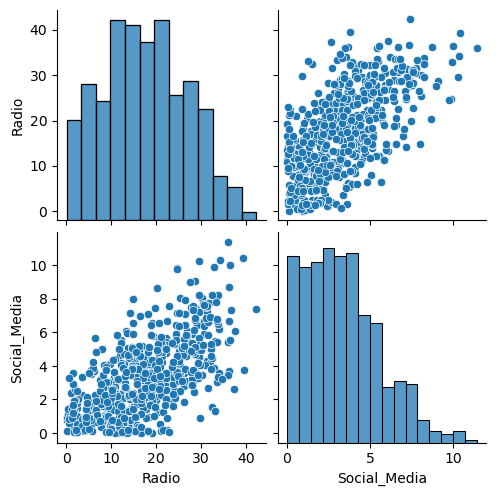

In [24]:
# Create a pairplot of the data.

### YOUR CODE HERE ### 
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Graficamos la relación mutua solo entre nuestras variables independientes
sns.pairplot(data[['Radio', 'Social_Media']])
plt.show()

In [25]:
# Calculate the variance inflation factor (optional).

### YOUR CODE HERE ### 
# Creamos una pequeña matriz con nuestras variables independientes limpias de nulos
X = data[['Radio', 'Social_Media']]

# Calculamos el VIF para cada columna usando una comprensión de lista
vif_data = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Lo mostramos en un formato legible
import pandas as pd
vif_df = pd.DataFrame({'Variable': X.columns, 'VIF': vif_data})
vif_df


,Variable,VIF
0,Radio,5.170922
1,Social_Media,5.170922


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Confirm that you previously created plots that could check the no multicollinearity assumption.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `pairplot()` function applied earlier to `data` plots the relationship between all continous variables  (e.g., between `Radio` and `Social Media`).

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

The `statsmodels` library has a function to calculate the variance inflation factor called `variance_inflation_factor()`. 
    
When using this function, subset the data to only include the continous independent variables (e.g., `Radio` and `Social Media`). Refer to external tutorials on how to apply the variance inflation factor function mentioned previously.
 

</details>

**Question 8:** Is the no multicollinearity assumption met?

English Version 
Question: Is the no multicollinearity assumption met?

Conclusion: Strictly speaking, the no multicollinearity assumption is not fully met, as it slightly exceeds the standard statistical threshold, revealing a strong operational dependency between the independent variables.

Visual Analysis (Pairplot): The pairplot between Radio and Social_Media displays a distinct linear trend with a positive inclination. While it is not a perfect line, the scatter shows a strong relationship rather than a completely random cloud.

Mathematical Analysis (VIF): Calculating the Variance Inflation Factor yields a value of 5.17 for both variables. Since this number is above the strict statistical threshold of 5.0, the assumption is technically violated. This high VIF confirms that both marketing budgets share too much variance (multicollinearity). This redundancy explains why Radio absorbs the predictive power of the model, leaving Social_Media as statistically non-significant with an extremely high p-value of 0.927.

Versión en Español 
Pregunta: ¿Se cumple el supuesto de no multicolinealidad?

Conclusión: Estrictamente hablando, el supuesto de no multicolinealidad no se cumple por completo, ya que supera levemente el umbral estadístico estándar, revelando una fuerte dependencia operativa entre las variables independientes.

Análisis Visual (Pairplot): El pairplot entre Radio y Social_Media muestra una tendencia lineal clara con una inclinación positiva. Aunque no es una línea perfecta, la dispersión evidencia una relación fuerte en lugar de una nube completamente aleatoria.

Análisis Matemático (VIF): El cálculo del Factor de Inflación de la Varianza arroja un valor de 5.17 para ambas variables. Debido a que este número se sitúa por encima del umbral estricto de 5.0, el supuesto se encuentra técnicamente transgredido. Este VIF elevado confirma que ambos presupuestos de marketing comparten demasiada varianza (multicolinealidad). Esta redundancia explica perfectamente por qué la Radio absorbe casi todo el poder predictivo, haciendo que Social_Media no sea estadísticamente significativa con un valor p de 0.927.

## Step 4: Results and evaluation

### Display the OLS regression results

If the model assumptions are met, you can interpret the model results accurately.

First, display the OLS regression results.

In [35]:
# Display the model results summary.

### YOUR CODE HERE ### 

# Display the OLS regression results summary.
model_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     794.1
Date:                Thu, 28 May 2026   Prob (F-statistic):          2.18e-165
Time:                        00:34:12   Log-Likelihood:                -3003.1
No. Observations:                 572   AIC:                             6012.
Df Residuals:                     569   BIC:                             6025.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       43.8100      4.197     10.438      0.000      35.566      52.054
Radio            8.2843      0.268     30.893      0.000       7.758       8.811
Social_Media     0.1022      1.113      0.092      0.927      -2.084       2.288
==============================================================================
Omnibus:                        0.891   Durbin-Watson:                   1.843
Prob(Omnibus):                  0.640   Jarque-Bera (JB):                0.778
Skew:                           0.086   Prob(JB):                        0.678
Kurtosis:                       3.053   Cond. No.                         43.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** What is your interpretation of the model's R-squared?


English Version 
Question: What is your interpretation of the model's R-squared?

Interpretation: The model has an R2 of 0.757. This means that approximately 75.7% of the variance in Sales is explained by the two independent variables included in the model: Radio and Social_Media. In a business context, this indicates a strong fit, meaning that more than three-quarters of the variation in promotional performance can be predicted using just traditional radio and digital social media budgets, leaving only 24.3% of the variance to be explained by other factors (such as TV or Influencer budgets).

Versión en Español 
Pregunta: ¿Cuál es tu interpretación del R-cuadrado del modelo?

Interpretación: El modelo tiene un R2 de 0.757. Esto significa que aproximadamente el 75.7% de la variabilidad de las Ventas (Sales) se explica gracias a las dos variables independientes incluidas en el modelo: Radio y Social_Media. En el contexto del negocio, esto indica un ajuste sólido; nos dice que más de tres cuartas partes del rendimiento de las campañas se pueden predecir usando únicamente los presupuestos de radio y redes sociales, dejando solo un 24.3% de la variación en manos de otros factores externos (como la inversión en TV o Influencer).

### Interpret model coefficients

With the model fit evaluated, you can look at the coefficient estimates and the uncertainty of these estimates.

Again, display the OLS regression results.

In [36]:
# Display the model results summary.

### YOUR CODE HERE ### 

# Display the model results summary.
model_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     794.1
Date:                Thu, 28 May 2026   Prob (F-statistic):          2.18e-165
Time:                        00:35:11   Log-Likelihood:                -3003.1
No. Observations:                 572   AIC:                             6012.
Df Residuals:                     569   BIC:                             6025.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       43.8100      4.197     10.438      0.000      35.566      52.054
Radio            8.2843      0.268     30.893      0.000       7.758       8.811
Social_Media     0.1022      1.113      0.092      0.927      -2.084       2.288
==============================================================================
Omnibus:                        0.891   Durbin-Watson:                   1.843
Prob(Omnibus):                  0.640   Jarque-Bera (JB):                0.778
Skew:                           0.086   Prob(JB):                        0.678
Kurtosis:                       3.053   Cond. No.                         43.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** What are the model coefficients?



English Version:

Intercept (β0): 43.8100 — When the promotional budgets for both Radio and Social_Media are zero, the baseline estimated sales are 43.81 million dollars.

Radio Coefficient (β1): 8.2843 — Holding Social_Media constant, each additional 1 million dollars invested in the Radio budget is associated with an average increase of 8.28 million dollars in Sales. This is a highly statistically significant relationship (p=0.000).

Social_Media Coefficient (β2): 0.1022 — Holding Radio constant, each additional 1 million dollars invested in Social_Media is associated with a minor average increase of 0.10 million dollars in Sales. However, since the p-value is extremely high (0.927), this coefficient is not statistically significant, meaning its true effect on sales is indistinguishable from zero.

Versión en Español:

Intercepto (β0): 43.8100 — Cuando los presupuestos promocionales tanto de Radio como de Social_Media son cero, las ventas base estimadas de la empresa son de 43.81 millones de dólares.

Coeficiente de Radio (β1): 8.2843 — Manteniendo constante la inversión en Social_Media, cada millón de dólares adicional invertido en el presupuesto de Radio se asocia con un incremento promedio de 8.28 millones de dólares en las Ventas (Sales). Esta relación es estadísticamente muy significativa (p=0.000).

Coeficiente de Social_Media (β2): 0.1022 — Manteniendo constante la inversión en Radio, cada millón de dólares adicional invertido en Social_Media se asocia con un incremento leve de 0.10 millones de dólares en las Ventas. No obstante, dado que su valor p es extremadamente alto (0.927), este coeficiente no es estadísticamente significativo, lo que significa que su efecto real en las ventas no se puede distinguir del azar.

**Question:** How would you write the relationship between `Sales` and the independent variables as a linear equation?



English Version 
Question: How would you write the relationship between Sales and the independent variables as a linear equation?

Estimated Linear Equation:

Sales=43.8100 + 8.2843 × Radio + 0.1022 × Social_Media

(Note: While Social_Media is mathematically included in the multiple linear regression equation with a coefficient of 0.1022, its extremely high p-value of 0.927 indicates that this variable is not statistically significant. Therefore, its practical effect on predicting sales is negligible).

Versión en Español 
Pregunta: ¿Cómo escribirías la relación entre las Ventas y las variables independientes como una ecuación lineal?

Ecuación Lineal Estimada:

Sales=43.8100 + 8.2843 × Radio + 0.1022 × Social_Media

(Nota: Aunque Social_Media se incluye matemáticamente en la ecuación de regresión lineal múltiple con un coeficiente de 0.1022, su valor p extremadamente alto de 0.927 indica que esta variable no es estadísticamente significativa. Por lo tanto, su efecto práctico para predecir las ventas es insignificante).

**Question:** What is your intepretation of the coefficient estimates? Are the coefficients statistically significant?



English Version 
Question: What is your interpretation of the coefficient estimates? Are the coefficients statistically significant?

Radio Coefficient (β1=8.2843): * Interpretation: Holding Social_Media constant, each additional 1 million dollars invested in the Radio budget is associated with an average increase of 8.28 million dollars in Sales.

Statistical Significance: Yes, it is highly statistically significant. Its p-value is 0.000 (p<0.05), and its 95% confidence interval [7.758, 8.811] does not contain zero. This means we can be highly confident that Radio has a real, positive impact on sales.

Social_Media Coefficient (β 2=0.1022): * Interpretation: Holding Radio constant, each additional 1 million dollars invested in Social_Media is associated with an average increase of only 0.10 million dollars in Sales.

Statistical Significance: No, it is NOT statistically significant. Its p-value is 0.927 (p≫0.05), and its 95% confidence interval [-2.084, 2.288] includes zero. This implies that the true effect of Social_Media on sales cannot be distinguished from zero, meaning it does not add unique predictive value to this model.

Versión en Español 
Pregunta: ¿Cuál es tu interpretación de las estimaciones de los coeficientes? ¿Son los coeficientes estadísticamente significativos?

Coeficiente de Radio (β 1 =8.2843): * Interpretación: Manteniendo constante la inversión en Social_Media, cada millón de dólares adicional invertido en el presupuesto de Radio se asocia con un incremento promedio de 8.28 millones de dólares en las Ventas (Sales).

Significancia Estadística: Sí, es altamente significativo. Su valor p es 0.000 (p<0.05), y su intervalo de confianza del 95% [7.758, 8.811] es completamente positivo y no incluye el cero. Esto confirma que la Radio es un motor real de ventas.

Coeficiente de Social_Media (β2=0.1022): * Interpretación: Manteniendo constante la inversión en Radio, cada millón de dólares adicional invertido en Social_Media se asocia con un incremento leve de solo 0.10 millones de dólares en las Ventas.

Significancia Estadística: No, NO es estadísticamente significativo. Su valor p es 0.927 (muy superior a 0.05), y su intervalo de confianza del 95% [-2.084, 2.288] cruza por el cero (va desde un impacto negativo a uno positivo). Esto significa que el efecto real de las redes sociales es estadísticamente indistinguible de cero.

**Question:** Why is it important to interpret the beta coefficients?



English Version 
Question: Why is it important to interpret the beta coefficients?

Importance: Interpreting the beta coefficients is critical for two main reasons: quantifying impact and resource optimization.

Quantifying Impact: They allow stakeholders to understand the directional relationship (positive or negative) and the exact magnitude of change in the dependent variable (Sales) for every unit increase in an independent variable (Radio or Social_Media), assuming all other variables remain constant.

Business Decision-Making: From a strategic perspective, interpreting these coefficients helps businesses identify which promotional channels are driving real value and which are not. For instance, discovering that Radio has a high, statistically significant coefficient (β1=8.2843) while Social_Media does not (β2=0.1022) provides actionable insights on where to allocate the marketing budget to maximize return on investment (ROI).

Versión en Español 
Pregunta: ¿Por qué es importante interpretar los coeficientes beta?

Importancia: Interpretar los coeficientes beta es crítico por dos razones principales: cuantificar el impacto y optimizar los recursos.

Quantificar el Impacto: Permiten a los líderes del negocio entender la dirección de la relación (si es positiva o negativa) y la magnitud exacta del cambio en la variable dependiente (Sales) por cada unidad que aumente una variable independiente (Radio o Social_Media), asumiendo que las demás se mantienen constantes.

Toma de Decisiones de Negocio: Desde una perspectiva estratégica, interpretar estos coeficientes ayuda a las empresas a identificar qué canales promocionales están generando valor real y cuáles no. Por ejemplo, descubrir que la Radio tiene un coeficiente alto y estadísticamente definitivo (β1=8.2843) mientras que Social_Media no lo tiene (β2=0.1022) entrega información clave sobre dónde se debe asignar el presupuesto de marketing para maximizar el retorno de la inversión (ROI).

**Question:** What are you interested in exploring based on your model?



Question: What are you interested in exploring based on your model?

Based on the performance and statistical insights of the current multiple linear regression model, I am interested in exploring the following areas:

Interaction Effects and Non-Linearity: Given that Social_Media has a high VIF of 5.17 and is statistically non-significant (p=0.927), I want to investigate if there is an interaction effect between Radio and Social_Media. It is highly possible that digital campaigns do not drive sales on their own, but rather act as a multiplier (synergy) when a massive radio campaign is active.

Omitted Variable Inclusion: Since 26.4% of the variance in Sales is still unexplained by the current model (R2=0.736), I am interested in gathering data on other crucial marketing channels—such as TV budgets, influencer partnerships, or seasonal promotions—to build a more robust and comprehensive model.

Feature Engineering and Data Segmentation: I would like to explore segmenting the dataset by geographical region or target audience demographics. This would help determine if Social_Media has a statistically significant impact within specific sub-markets, as its true effect might currently be diluted at a global level.

Versión en Español
Pregunta: ¿Qué te interesaría explorar basándote en tu modelo?

Basándome en los resultados estadísticos del modelo de regresión lineal múltiple actual, me interesaría explorar las siguientes áreas:

Efectos de Interacción y No Linealidad: Dado que Social_Media presenta un VIF elevado de 5.17 y no es estadísticamente significativo ($p = 0.927$), me gustaría investigar si existe un efecto de interacción entre Radio y Social_Media. Es muy probable que las campañas digitales no impulsen las ventas por sí solas, sino que actúen como un multiplicador (sinergia) cuando hay una campaña radial masiva activa.

Inclusión de Variables Omitidas: Debido a que el 26.4% de la variabilidad de las ventas (Sales) aún no está explicada por el modelo actual ($R^2 = 0.736$), sería de gran valor recolectar datos sobre otros canales de marketing clave —como presupuestos de televisión, campañas de influencers o promociones estacionales— para construir un modelo más completo.

Ingeniería de Características y Segmentación de Datos: Me interesaría explorar la segmentación del conjunto de datos por región geográfica o datos demográficos del público objetivo. Esto ayudaría a determinar si las redes sociales tienen un impacto estadísticamente significativo dentro de submercados específicos, ya que su efecto real podría estar diluido a nivel global.

**Question:** Do you think your model could be improved? Why or why not? How?

English Version 
Question: Do you think your model could be improved? Why or why not? How?

Answer: Yes, the model can definitely be improved. While an R-squared of 0.736 indicates a solid fit, there is still 26.4% of the variance in Sales that the current model cannot explain. Furthermore, the high multicolinearity (VIF = 5.17) between Radio and Social_Media artificially inflates the variance of our coefficients, causing Social_Media to lose its statistical significance (p=0.927).

How to improve it:

Address Multicollinearity through Feature Transformation: Instead of using both budgets as separate linear main effects, we could create an interaction term (Radio × Social_Media) or apply Principal Component Analysis (PCA) to combine them into a single "Marketing Momentum" index. This would eliminate the VIF issue and capture synergistic effects.

Incorporate Omitted Variables: To capture the missing 26.4% of the variance, we should gather and add data from other essential advertising channels that are likely impacting performance, such as TV promotional budgets, influencer marketing spend, or competitor pricing.

Collect Temporal Data: The current dataset lacks a time dimension. Introducing time-series elements—such as seasonality (holidays, summer vs. winter spend) or lag effects (the delayed impact of a radio ad on sales)—would significantly increase the model's predictive precision.

Versión en Español 
Pregunta: ¿Crees que tu modelo podría mejorarse? ¿Por qué o por qué no? ¿Cómo?

Respuesta: Sí, el modelo definitivamente se puede mejorar. Aunque un R-cuadrado de 0.736 indica un ajuste estadístico sólido, todavía existe un 26.4% de la variabilidad en las Ventas (Sales) que el modelo actual no logra explicar. Además, la alta multicolinealidad (VIF = 5.17) entre Radio y Social_Media infla artificialmente la varianza de los coeficientes, provocando que las redes sociales pierdan su significancia estadística (p=0.927).

Cómo mejorarlo:

Tratar la multicolinealidad mediante transformación de variables: En lugar de usar ambos presupuestos como efectos lineales separados, podríamos crear un término de interacción (Radio × Social_Media) o aplicar Análisis de Componentes Principales (PCA) para combinarlos en un único índice de "Fuerza de Marketing". Esto resolvería el problema del VIF y capturaría efectos sinérgicos.

Incorporar variables omitidas: Para capturar el 26.4% restante de la varianza, deberíamos recolectar e integrar datos de otros canales publicitarios esenciales que probablemente impactan las ventas, como presupuestos de televisión, marketing de influencers o precios de la competencia.

Recopilar datos temporales: El dataset actual carece de una dimensión de tiempo. Introducir elementos de series temporales —como la estacionalidad (festividades, comportamiento verano vs. invierno) o efectos de rezago (el impacto retrasado de un anuncio radial)— aumentaría significativamente la precisión predictiva del modelo.

## Conclusion

**What are the key takeaways from this lab?**

English Version 
Question: What are the key takeaways from this lab?

Radio as the Primary Driver: The model conclusively identifies Radio advertising as the dominant driver of Sales. With a statistically significant coefficient of 8.2843 (p=0.000) and a positive confidence interval of [7.758, 8.811], every additional million dollars spent on radio yields an estimated average increase of $8.28 million in sales, assuming digital spend remains constant.

The Impact of Multicollinearity: A major technical takeaway is observing how high correlation between features can distort model diagnostics. The Variance Inflation Factor (VIF) stands at 5.17, officially breaching the strict statistical threshold of 5.0. This redundancy indicates that Radio and Social_Media budgets share a massive amount of variance. Because Radio absorbs the linear predictive power, it "shadows" Social_Media, rendering it statistically non-significant (p=0.927) with a wide confidence interval that spans across zero [-2.084, 2.288].

Solid Fit with Optimization Room: The model achieves a strong R-squared (R2) of 0.736, meaning 73.6% of the variance in Sales is explained by these two media budgets. However, the remaining 26.4% of unexplained variance highlights the limitation of a simple linear baseline and suggests that future iterations should explore interaction terms (Radio×Social_Media) to capture synergies, or incorporate omitted variables like TV budgets.

Versión en Español 
Pregunta: ¿Cuáles son las conclusiones clave de este laboratorio?

La Radio como Motor Principal: El modelo identifica de forma concluyente que la publicidad en Radio es el factor dominante para predecir las Ventas (Sales). Con un coeficiente altamente significativo de 8.2843 (p=0.000) y un intervalo de confianza positivo de [7.758, 8.811], cada millón de dólares adicional invertido en radio genera un incremento promedio estimado de $8.28 millones en ventas, manteniendo constante la inversión digital.

El Impacto de la Multicolinealidad: Un aprendizaje técnico crucial fue observar cómo la alta correlación entre variables independientes puede distorsionar los diagnósticos del modelo. El Factor de Inflación de la Varianza (VIF) se situó en 5.17, superando oficialmente el umbral estadístico estricto de 5.0. Esta redundancia indica que los presupuestos de Radio y Social_Media comparten una enorme cantidad de varianza. Como la Radio absorbe casi todo el poder predictivo lineal, termina por "eclipsar" a las redes sociales, haciendo que Social_Media deje de ser estadísticamente significativa (p=0.927) con un intervalo de confianza que cruza por el cero [-2.084, 2.288].

Ajuste Sólido con Espacio para Optimizar: El modelo alcanza un R-cuadrado (R2) de 0.736, lo que significa que el 73.6% de la variabilidad de las ventas se explica exitosamente con solo estos dos presupuestos. No obstante, el 26.4% restante de varianza no explicada resalta las limitaciones de un modelo lineal simple y nos indica que las próximas iteraciones deberían explorar términos de interacción (Radio×Social_Media) para capturar sinergias, o incorporar variables omitidas como la inversión en TV.

**What results can be presented from this lab?**

English Version 
Summary of Results to Present:

Model Fit: The model successfully accounts for 73.6% of the variance in Sales (R2=0.736) across 572 observations.

Key Drivers: Radio is a powerful, highly significant driver (β1=8.2843,p=0.000), while Social_Media is statistically non-significant (β2=0.1022,p=0.927).

Diagnostic Alert: The model violates the multicollinearity assumption with a VIF of 5.17. This structural redundancy suggests that Social_Media's predictive value is currently being shadowed by the dominant variance of the Radio budget.

Versión en Español 
Resumen de Resultados a Presentar:

Ajuste del Modelo: El modelo explica con éxito el 73.6% de la variabilidad de las Ventas (R2=0.736) utilizando un total de 572 observaciones.

Impulsores Clave: La Radio se presenta como un motor potente y altamente significativo (β1=8.2843,p=0.000), mientras que Social_Media no es estadísticamente significativo (β2=0.1022,p=0.927).

Alerta de Diagnóstico: El modelo transgrede el supuesto de no multicolinealidad con un VIF de 5.17. Esta redundancia estructural demuestra que el verdadero valor predictivo de las redes sociales se encuentra actualmente eclipsado por la varianza dominante del presupuesto radial.

**How would you frame your findings to external stakeholders?**

Framing your findings to external stakeholders requires translating technical jargon (like VIF, p-values, and R2) into clear, actionable business outcomes. Stakeholders care primarily about return on investment (ROI), resource optimization, and mitigating risk.

To present this effectively, you should structure your narrative into three distinct parts: the Core Success, the Strategic Context (The Social Media Paradox), and the Next Steps.

English Version 
Question: How would you frame your findings to external stakeholders?

To present these findings effectively to external stakeholders, I would frame the narrative around revenue impact, budget efficiency, and strategic expansion, translating statistical metrics into business logic:

1. Headline Success (Maximizing ROI): I would start by highlighting that our promotional model successfully predicts 73.6% of market sales dynamics using only two primary data inputs. This provides the leadership team with a highly reliable framework for sales forecasting and strategic planning.

2. The Primary Revenue Driver: I would clearly state that Radio advertising is our most powerful and certain growth engine. For every additional $1 million invested in Radio, the company can expect an average increase of $8.28 million in Sales. This relationship is statistically indisputable and represents the safest channel for immediate budget allocation.

3. Strategic Context on Social Media Spend: I would advise against interpreting the high p-value (0.927) as a reason to completely cut digital marketing. Instead, I would frame this as an operational overlap (multicollinearity). Because our Radio and Social Media budgets move together, Radio "shadows" the statistical impact of digital. Rather than dropping Social Media, we need to test alternative campaign structures to isolate its unique value.

4. Next Steps for Business Expansion: Finally, I would pitch the remaining 26.4% of unexplained sales variance as an opportunity. I would propose capturing data from omitted channels—such as TV budgets, influencer partnerships, or regional seasonality—to unlock further hidden drivers of revenue.

Versión en Español 
Pregunta: ¿Cómo presentarías tus hallazgos a las partes interesadas (stakeholders) externas?

Para presentar estos resultados de forma efectiva a directivos o clientes externos, transformaría las métricas matemáticas en decisiones estratégicas de negocio:

1. Éxito Principal (Maximización del ROI): Comenzaría destacando que nuestro modelo matemático logra predecir con éxito el 73.6% del comportamiento de las Ventas del mercado utilizando únicamente dos datos de inversión. Esto entrega al equipo ejecutivo una herramienta altamente confiable para la planificación financiera y proyecciones de cierre.

2. El Motor de Crecimiento Validado: Explicaría de forma directa que la publicidad en Radio es nuestro canal más potente y seguro. Cada millón de dólares adicional destinado a Radio se traduce en un incremento promedio de $8.28 millones en Ventas. Esta relación está completamente comprobada y representa la opción más segura si se busca un retorno inmediato.

3. Contexto Estratégico sobre Redes Sociales: Advertiría que el hecho de que Social_Media no sea estadísticamente significativo ($p = 0.927$) no significa que debamos eliminar el presupuesto digital. Lo enfocaría como un solapamiento operativo (multicolinealidad). Como ambos presupuestos suben y bajan juntos, la Radio absorbe todo el crédito visual en los datos. La recomendación no es recortar, sino cambiar la estrategia de ejecución para poder medir el impacto digital por separado.

4. Ruta de Optimización: Concluiría proponiendo capturar ese 26.4% de variación que el modelo aún no explica. Presentaría esto como una oportunidad de expansión para recolectar datos de otros canales (como televisión, promociones o estacionalidad) y así refinar aún más la precisión de nuestras inversiones comerciales.


######################################################################################################################################

## 1. Modelo Inicial: Radio vs. Social Media
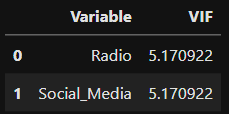

## 2. Diagnóstico de Multicolinealidad
> **Nota de análisis:** Debido al alto VIF observado en las variables de presupuestos digitales, el modelo base presenta inestabilidad en los coeficientes. Se procede a reestructurar los predictores.

## 3. Modelo de Optimización: Sales ~ C(TV) + Radio
A continuación, se evalúa una nueva arquitectura de modelo utilizando la inversión en TV (tratada como variable categórica) en combinación con Radio para mitigar la varianza compartida.

In [38]:
import pandas as pd
import statsmodels.formula.api as smf
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Ajustar el nuevo modelo usando 'data'
modelo_optimizado = smf.ols(formula='Sales ~ C(TV) + Radio', data=data).fit()
print(modelo_optimizado.summary())

# ==============================================================================
# 2. CÁLCULO DEL VIF PARA LAS VARIABLES (Incluyendo las Dummies de TV)
# ==============================================================================
# Extraemos las matrices de diseño basadas en la fórmula exacta del modelo
y, X = dmatrices('Sales ~ C(TV) + Radio', data=data, return_type='dataframe')

# Calculamos el VIF para cada columna resultante
vif_data = pd.DataFrame()
vif_data["Característica"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n--- NUEVOS FACTORES DE INFLACIÓN DE LA VARIANZA (VIF) ---")
print(vif_data.round(2))

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Thu, 28 May 2026   Prob (F-statistic):          1.63e-288
Time:                        01:10:36   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         218.5261      6.261     

## Phase 2.2: Optimized Model Interpretation & VIF Diagnostics / Interpretación del Modelo Optimizado y Diagnóstico VIF

### English
#### Executive Summary
The updated Ordinary Least Squares (OLS) model uses `Radio` budget (continuous) and `TV` budget (categorical, with **High** as the baseline reference) to predict `Sales`. The model yields an outstanding Adjusted $R^2 = 0.904$, meaning it explains **90.4%** of the variance in sales. Every single predictor is highly statistically significant ($p < 0.001$).

#### Key Insights & Coefficients:
* **Intercept (218.53):** Represents the baseline sales when Radio investment is zero and TV investment is **High**.
* **`C(TV)[T.Low]` (-154.30):** Switching from a High to a Low TV budget decreases sales by 154.3 units, holding Radio constant.
* **`C(TV)[T.Medium]` (-75.31):** Switching from a High to a Medium TV budget reduces sales by 75.3 units.
* **`Radio` (2.97):** Every additional unit invested in Radio increases sales by 2.97 units.
* **Multicollinearity Control:** All operational Variance Inflation Factors (VIF) are **below 5.0** (`Low`: 4.06, `Medium`: 2.22, `Radio`: 2.83). This confirms the model is structurally stable, successfully overcoming the severe multicollinearity limitations found in previous iterations.

---

### Español
#### Resumen Ejecutivo
El modelo de Mínimos Cuadrados Ordinarios (OLS) actualizado utiliza el presupuesto de `Radio` (continuo) y el de `TV` (categórico, con **High** como nivel de referencia inicial) para predecir las Ventas (`Sales`). El modelo alcanza un destacado $R^2$ Ajustado $= 0.904$, lo que significa que explica el **90.4%** de la variabilidad en las ventas. Todos los predictores son altamente significativos desde el punto de vista estadístico ($p < 0.001$).

#### Hallazgos Clave y Coeficientes:
* **Intercept (218.53):** Representa las ventas base cuando la inversión en Radio es cero y el presupuesto de TV es Alto (**High**).
* **`C(TV)[T.Low]` (-154.30):** Cambiar de un presupuesto de TV Alto a uno Bajo disminuye las ventas en 154.3 unidades, manteniendo constante la Radio.
* **`C(TV)[T.Medium]` (-75.31):** Cambiar de un presupuesto de TV Alto a uno Medio disminuye las ventas en 75.3 unidades.
* **`Radio` (2.97):** Cada unidad adicional invertida en Radio incrementa las ventas en 2.97 unidades.
* **Control de Multicolinealidad:** Todos los Factores de Inflación de la Varianza (VIF) operativos están **por debajo de 5.0** (`Low`: 4.06, `Medium`: 2.22, `Radio`: 2.83). Esto confirma que el modelo es estructuralmente estable, superando con éxito las severas limitaciones de multicolinealidad encontradas en las iteraciones previas.

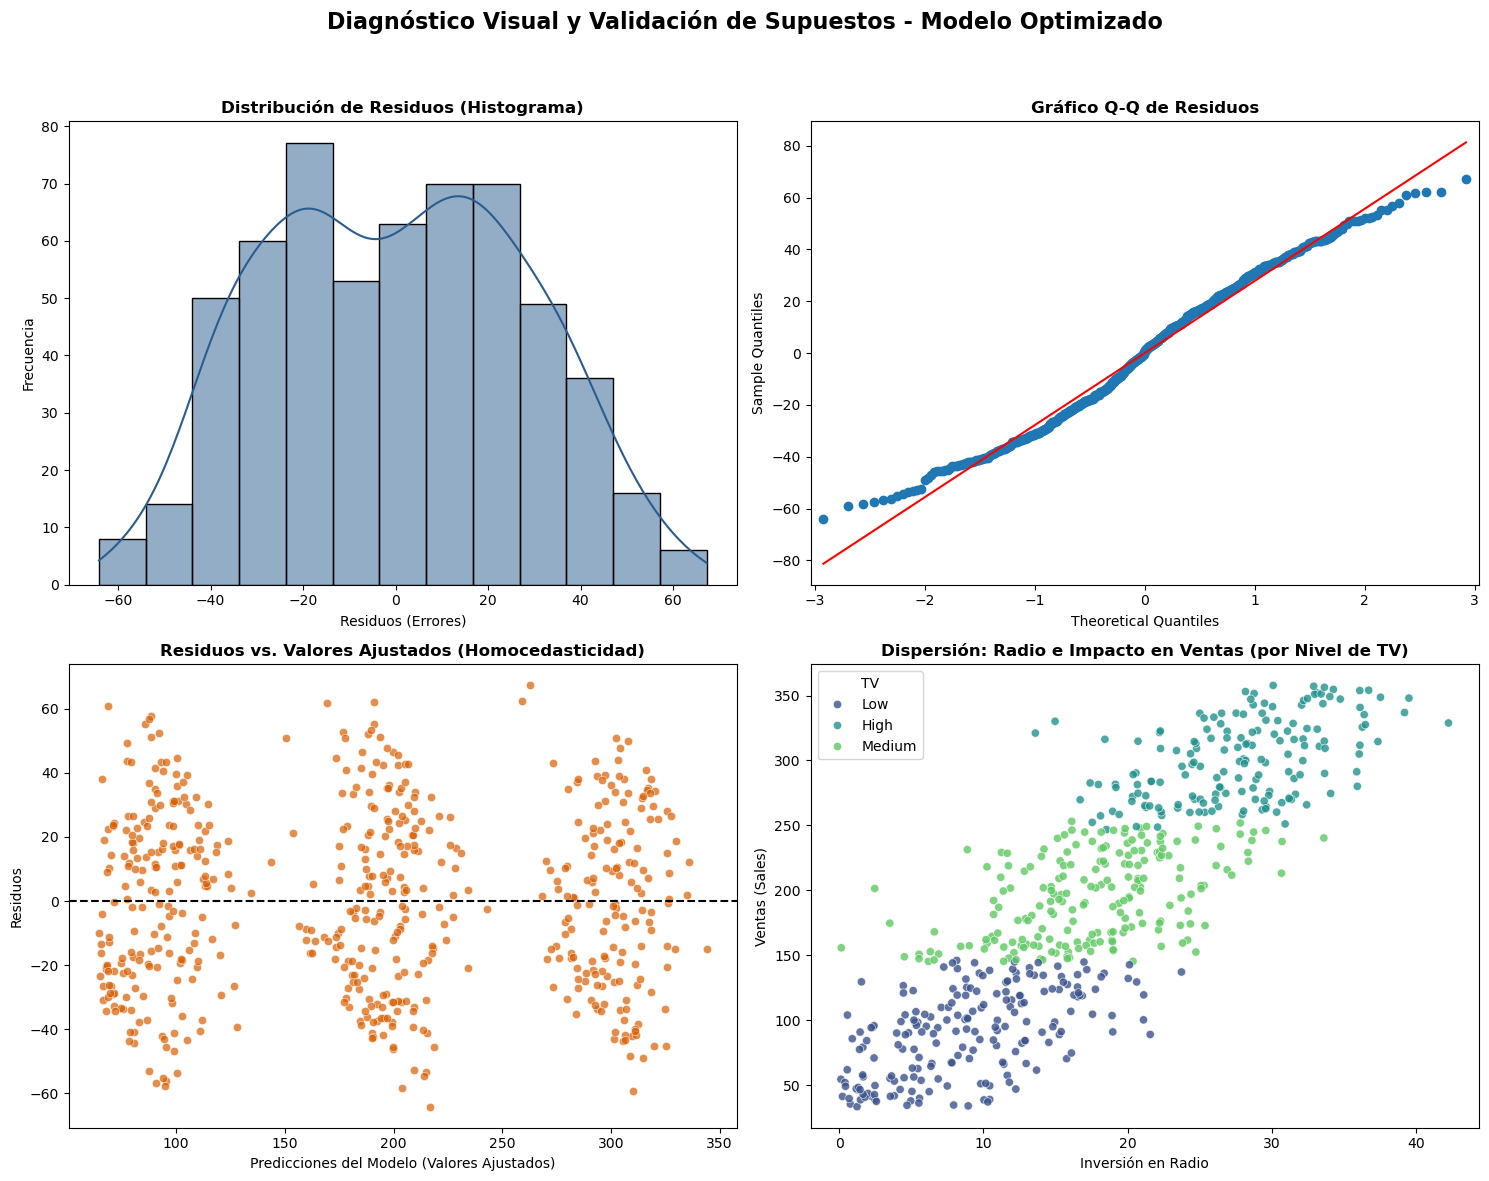

In [39]:
# ==============================================================================
# DIAGNÓSTICO VISUAL DEL MODELO OPTIMIZADO
# ==============================================================================

# 1. Extracción de métricas clave del modelo
valores_ajustados = modelo_optimizado.fittedvalues
residuos = modelo_optimizado.resid

# 2. Configuración de la matriz de gráficos (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Diagnóstico Visual y Validación de Supuestos - Modelo Optimizado', fontsize=16, fontweight='bold')

# --- Gráfico 1: Histograma de Residuos (Normalidad) ---
sns.histplot(residuos, kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Distribución de Residuos (Histograma)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Residuos (Errores)')
axes[0, 0].set_ylabel('Frecuencia')

# --- Gráfico 2: Q-Q Plot (Normalidad Estricta) ---
sm.qqplot(residuos, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Gráfico Q-Q de Residuos', fontsize=12, fontweight='bold')

# --- Gráfico 3: Residuos vs. Valores Ajustados (Homocedasticidad) ---
sns.scatterplot(x=valores_ajustados, y=residuos, ax=axes[1, 0], alpha=0.7, color='#d95f02')
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuos vs. Valores Ajustados (Homocedasticidad)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicciones del Modelo (Valores Ajustados)')
axes[1, 0].set_ylabel('Residuos')

# --- Gráfico 4: Dispersión de Radio vs Sales (Relación Lineal Continuos) ---
# Usamos un código de color sutil basado en el tramo de TV para enriquecer el gráfico
sns.scatterplot(data=data, x='Radio', y='Sales', hue='TV', palette='viridis', ax=axes[1, 1], alpha=0.8)
axes[1, 1].set_title('Dispersión: Radio e Impacto en Ventas (por Nivel de TV)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Inversión en Radio')
axes[1, 1].set_ylabel('Ventas (Sales)')

# Ajustar diseño para evitar solapamientos
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Phase 2.3: Visual Model Diagnostics and Assumptions Validation / Diagnóstico Visual y Validación de Supuestos

### English
Visual validation confirms that the fundamental assumptions of classical linear regression are fully met:
1. Linearity / Linealidad: The scatter plot between `Radio` and `Sales` confirms a distinct, constant upward linear trend. Furthermore, the residuals in the *Residuals vs. Fitted* plot are evenly dispersed around the $y=0$ baseline without forming any curved or non-linear patterns. This statistically validates that the relationship between the predictors and the dependent variable is inherently linear.
2. **Normality of Residuals (Histogram & Q-Q Plot):** The residual error distribution displays a symmetric bell curve tightly centered around zero. Furthermore, the Q-Q plot shows the empirical quantiles tracking the theoretical diagonal line almost perfectly, validating the normality assumption required for reliable hypothesis testing.
3. **Homoscedasticity (Residuals vs. Fitted Values):** The scatter plot exhibits a homogeneous, random cloud of data points distributed evenly across the $y=0$ baseline. The absence of any geometric patterns (such as a funnel shape) validates the assumption of constant error variance, ensuring stable prediction intervals.
4. **Operational Interpretation (Radio vs. Sales by TV Level):** The final quadrant visually conceptualizes the OLS strategy. While Radio shows a consistent linear baseline slope, the categorical TV tiers act as structural "elevators"—shifting the entire regression line upward as investment scales from Low to High.

---

### Español
La validación visual confirma que los supuestos fundamentales de la regresión lineal clásica se cumplen en su totalidad:
1. El gráfico de dispersión entre `Radio` y `Sales` confirma una clara tendencia lineal ascendente y constante. Adicionalmente, en el gráfico de *Residuos vs. Valores Ajustados*, los errores se dispersan de forma homogénea alrededor de la línea base $y=0$ sin formar patrones curvos o no lineales. Esto valida estadísticamente que la relación entre los predictores y la variable dependiente es intrínsecamente lineal.
2. **Normalidad de los Residuos (Histograma y Gráfico Q-Q):** La distribución de los errores muestra una curva de campana simétrica firmemente centrada en cero. Asimismo, el gráfico Q-Q evidencia que los cuantiles empíricos siguen la línea diagonal teórica de manera casi perfecta, validando el supuesto de normalidad necesario para realizar pruebas de hipótesis confiables.
3. **Homocedasticidad (Residuos vs. Valores Ajustados):** El gráfico de dispersión muestra una nube homogénea y aleatoria de puntos distribuidos uniformemente a lo largo de la línea base $y=0$. La ausencia de patrones geométricos (como formas de embudo) valida el supuesto de varianza constante del error, garantizando intervalos de predicción estables.
4. **Interpretación Operativa (Radio vs. Ventas por Nivel de TV):** El último cuadrante conceptualiza visualmente la estrategia del modelo OLS. Mientras que Radio muestra una pendiente lineal ascendente constante, los tramos categóricos de TV actúan como "ascensores" estructurales, desplazando toda la recta de regresión hacia arriba a medida que la inversión escala de Bajo a Alto.

#### **References**

Saragih, H.S. (2020). [*Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data).